# 🚀 Research-Grade Pruning Framework (V7 - Dual Framework Edition)

### ✨ New in V7:
1.  **Dual Backend**: Support for both **PyTorch** and **Keras/TensorFlow**.
2.  **Shared Architecture**: Refactored reusable logic into a common `FrameworkAdapter`.
3.  **Advanced Decorators**: Usage of `@timer` and `@logger` for clean execution tracking.
4.  **Post-Training Viz**: Baseline visualizations are now captured *after* the model has learned CIFAR features.
5.  **Multi-Layer Activation Scale**: Colorbars and labels for feature maps across the first 3 layers.

⚠️ You are on a remote Colab runtime, so checkpoints are saved to /content. Direct writes to C:/ local disk are not possible from this runtime.
📁 Checkpoints directory: /content/saved_models

🧪 Running Keras method validation suite...
✂️ Keras pruning masks built with method='l1_norm', scope='local', ratio=0.3
✂️ Keras pruning masks built with method='l1_norm', scope='global', ratio=0.3
✂️ Keras pruning masks built with method='l2_norm', scope='local', ratio=0.3
✂️ Keras pruning masks built with method='l2_norm', scope='global', ratio=0.3
✂️ Keras pruning masks built with method='mean_abs_act', scope='local', ratio=0.3
✂️ Keras pruning masks built with method='mean_abs_act', scope='global', ratio=0.3
✂️ Keras pruning masks built with method='apoz', scope='local', ratio=0.3
✂️ Keras pruning masks built with method='apoz', scope='global', ratio=0.3
✂️ Keras pruning masks built with method='variance_act', scope='local', ratio=0.3
✂️ Keras pruning masks built with method='variance_act', sc

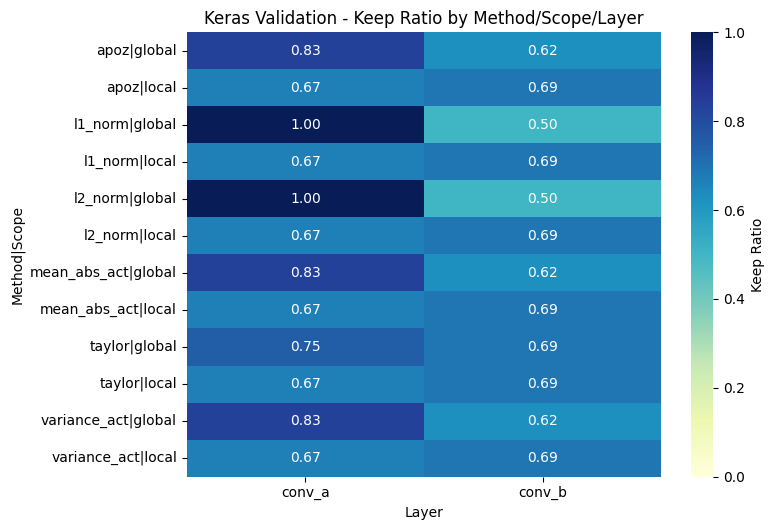

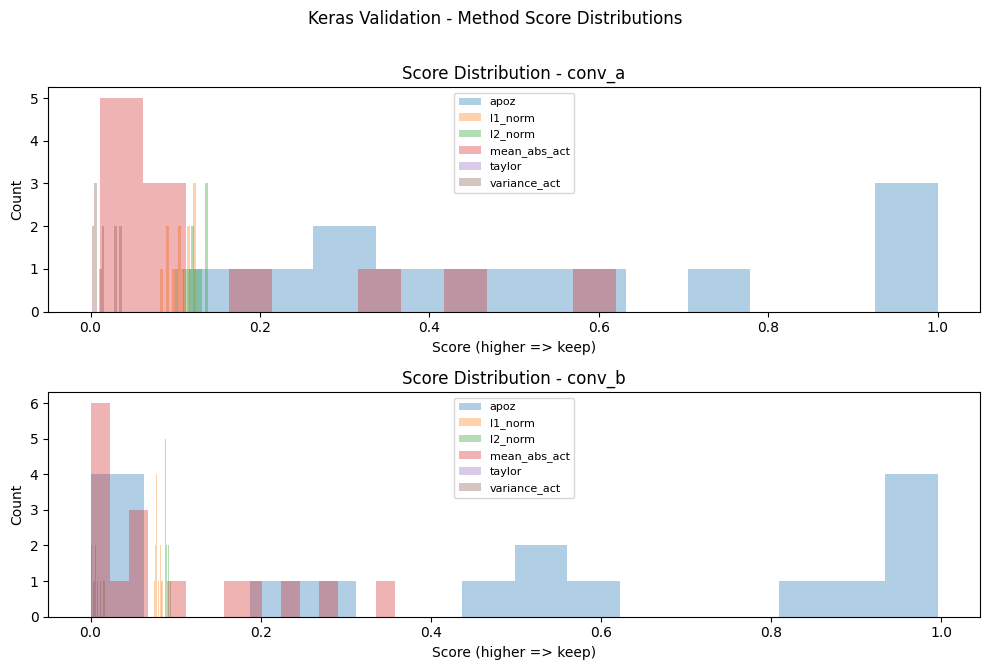

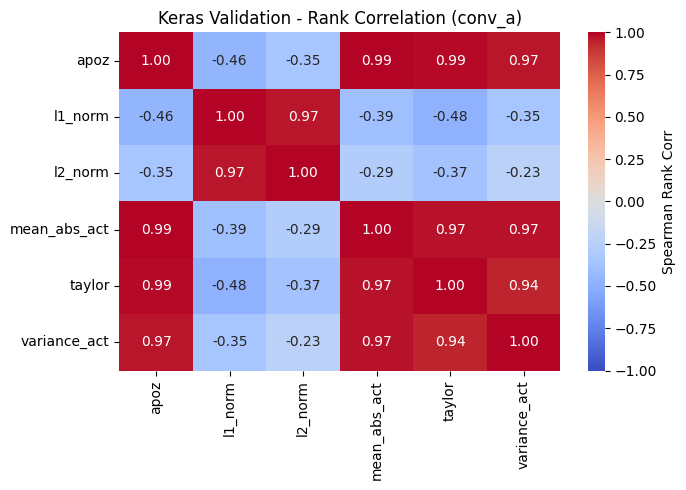

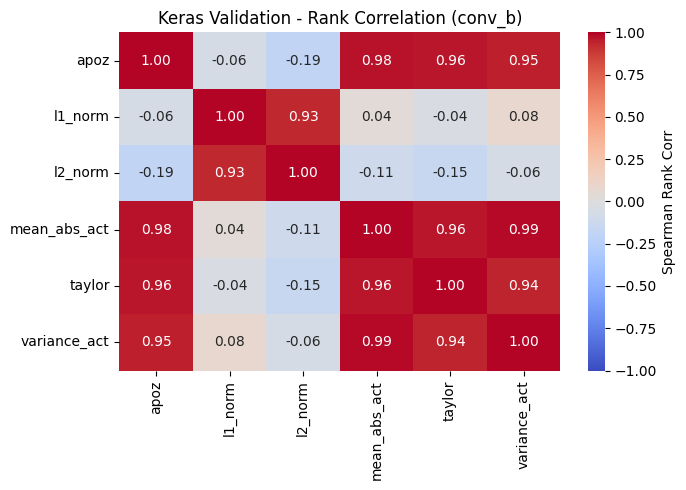

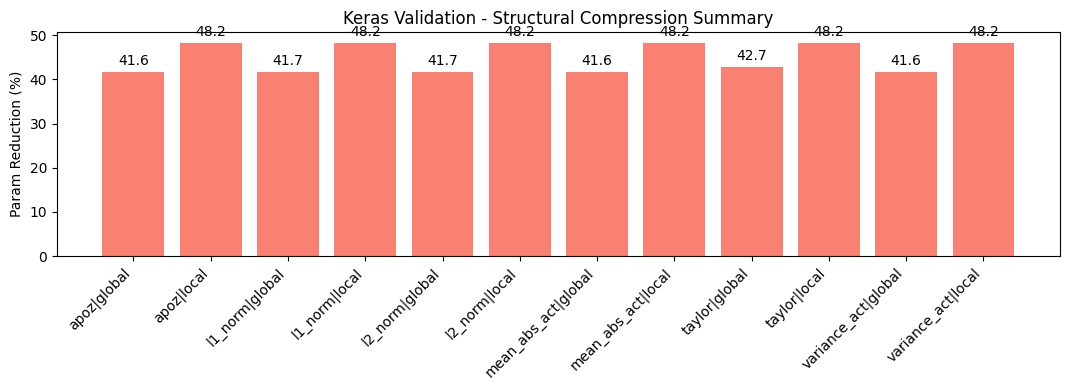

✅ Keras method validation suite passed.

--- Generating Pareto Frontier ---
📈 Generating Accuracy vs Efficiency Pareto Frontier for ratios: [0.2, 0.4, 0.6, 0.8]

--- Testing Prune Ratio: 0.2 ---
✂️ Keras pruning masks built with method='taylor', scope='local', ratio=0.2

--- Testing Prune Ratio: 0.4 ---
✂️ Keras pruning masks built with method='taylor', scope='local', ratio=0.4

--- Testing Prune Ratio: 0.6 ---
✂️ Keras pruning masks built with method='taylor', scope='local', ratio=0.6

--- Testing Prune Ratio: 0.8 ---
✂️ Keras pruning masks built with method='taylor', scope='local', ratio=0.8


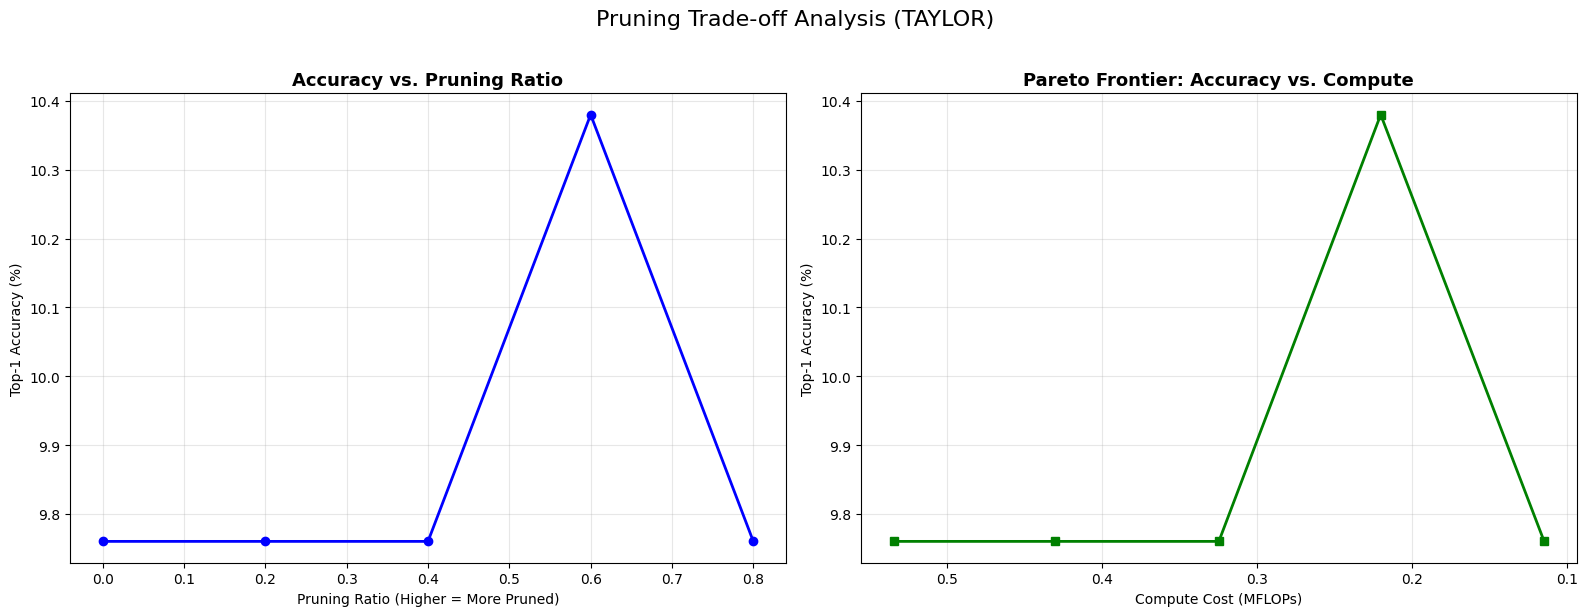


--- Starting Pruning Pipeline ---
🚀 Training Baseline...
Baseline Epoch 1/15 | train_loss=1.3144 train_acc=52.71% | val_loss=1.3170 val_acc=55.88%
Baseline Epoch 2/15 | train_loss=0.8757 train_acc=68.99% | val_loss=1.0613 val_acc=65.96%
Baseline Epoch 3/15 | train_loss=0.6884 train_acc=76.09% | val_loss=1.5564 val_acc=54.30%
Baseline Epoch 4/15 | train_loss=0.5657 train_acc=80.45% | val_loss=0.7649 val_acc=74.98%
Baseline Epoch 5/15 | train_loss=0.4847 train_acc=83.49% | val_loss=0.7864 val_acc=74.76%
Baseline Epoch 6/15 | train_loss=0.4112 train_acc=85.81% | val_loss=0.7571 val_acc=75.68%
Baseline Epoch 7/15 | train_loss=0.3469 train_acc=88.17% | val_loss=0.7083 val_acc=78.36%
Baseline Epoch 8/15 | train_loss=0.3028 train_acc=89.67% | val_loss=0.8998 val_acc=75.56%
Baseline Epoch 9/15 | train_loss=0.2681 train_acc=90.83% | val_loss=0.6189 val_acc=80.16%
Baseline Epoch 10/15 | train_loss=0.2260 train_acc=92.38% | val_loss=0.7527 val_acc=78.50%
Baseline Epoch 11/15 | train_loss=0.1969 

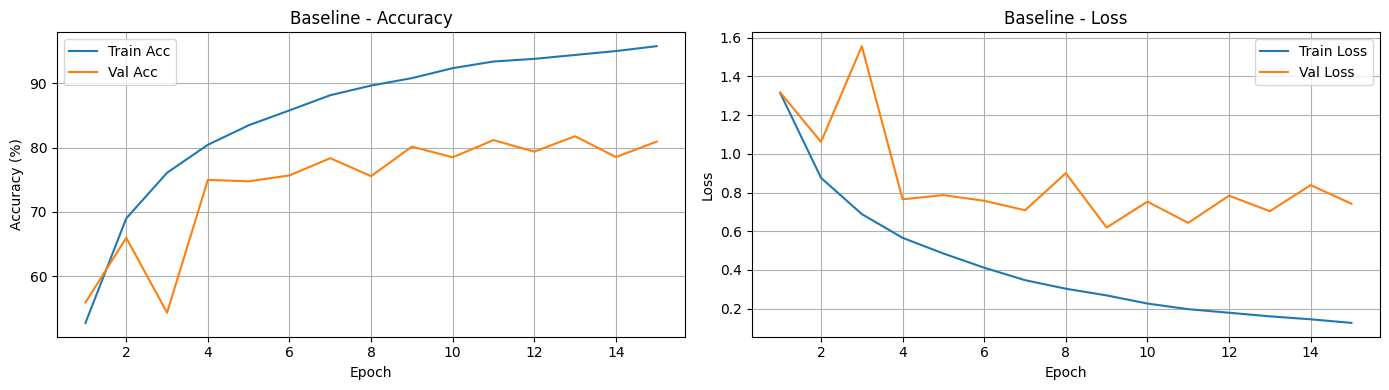

🖼️ Visualizing Baseline (Post-Training)...


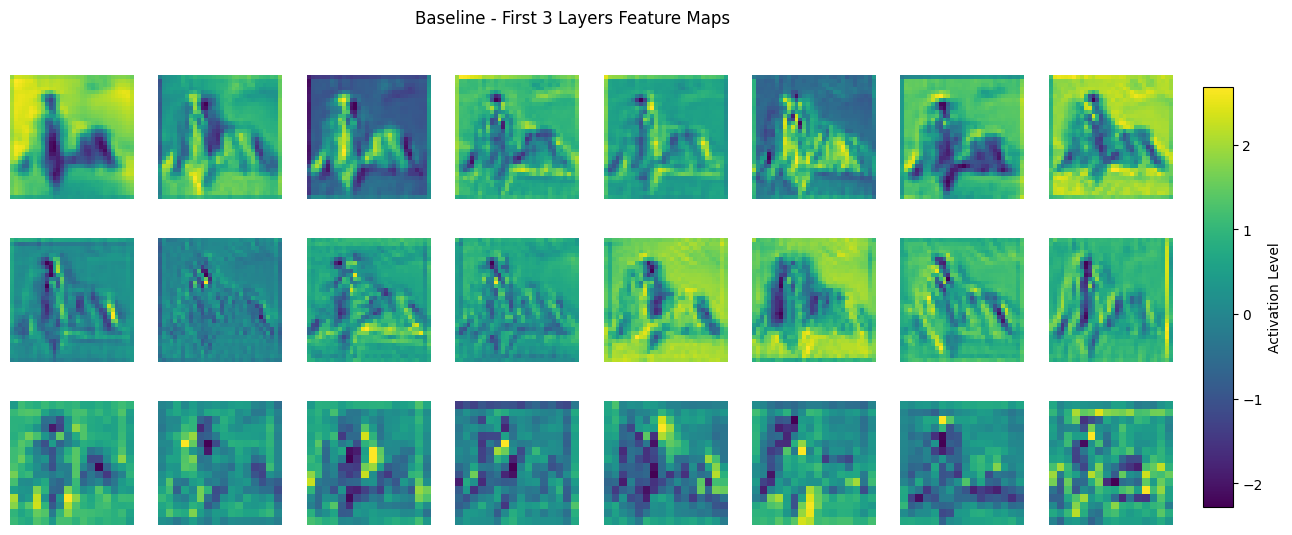

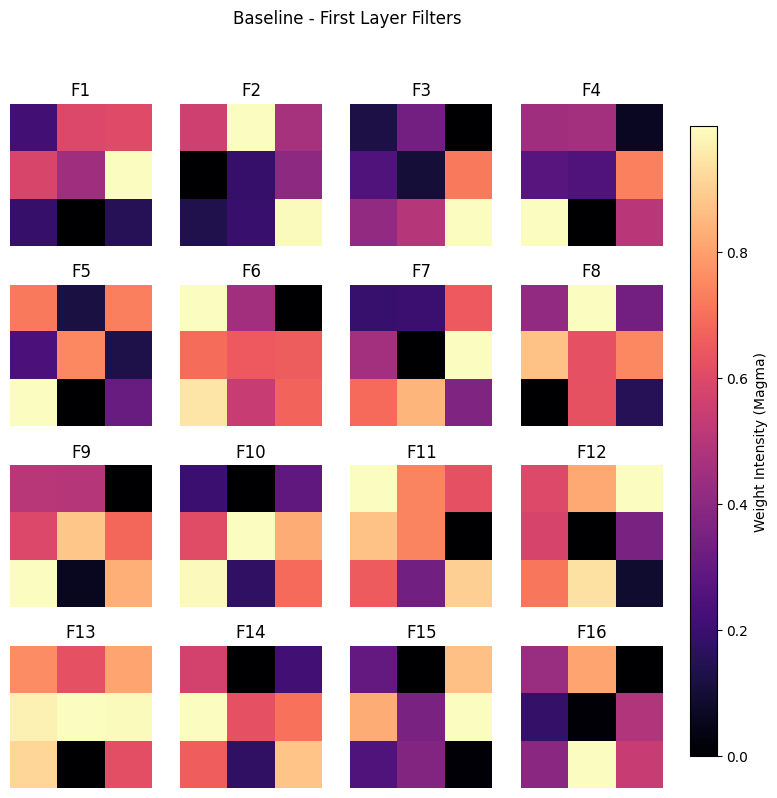

📊 Baseline Accuracy: 80.94%
✂️ Applying Surgical Pruning...
✂️ Keras pruning masks built with method='taylor', scope='local', ratio=0.4
🔥 Fine-Tuning Pruned Model...
Pruned Epoch 1/5 | train_loss=0.5501 train_acc=81.17% | val_loss=0.6295 val_acc=79.08%
Pruned Epoch 2/5 | train_loss=0.3345 train_acc=88.55% | val_loss=0.6533 val_acc=79.26%
Pruned Epoch 3/5 | train_loss=0.2622 train_acc=91.10% | val_loss=0.6929 val_acc=80.04%
Pruned Epoch 4/5 | train_loss=0.2211 train_acc=92.45% | val_loss=0.6108 val_acc=81.58%
Pruned Epoch 5/5 | train_loss=0.1840 train_acc=93.64% | val_loss=0.6045 val_acc=82.32%
💾 Saved Keras weights for Pruned to /content/saved_models/v7_exp_vgg16_Pruned.weights.h5
⏱️ train took 116.14s


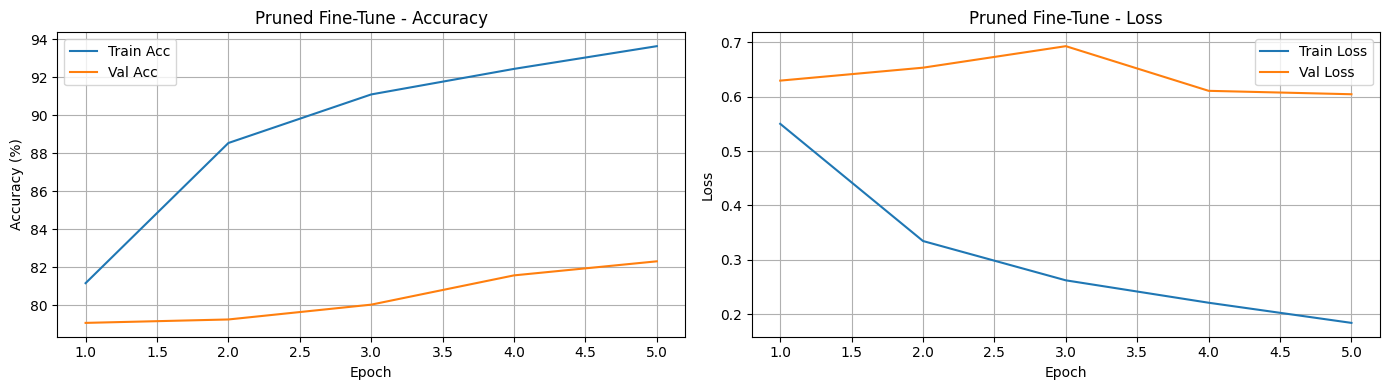

🖼️ Visualizing Pruned Model...


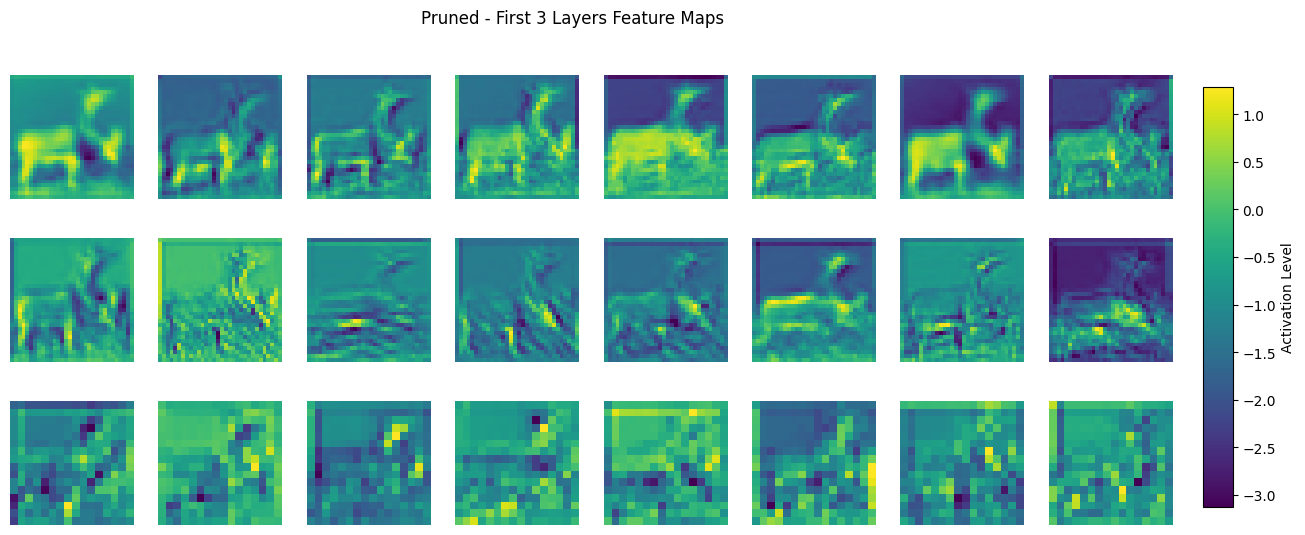

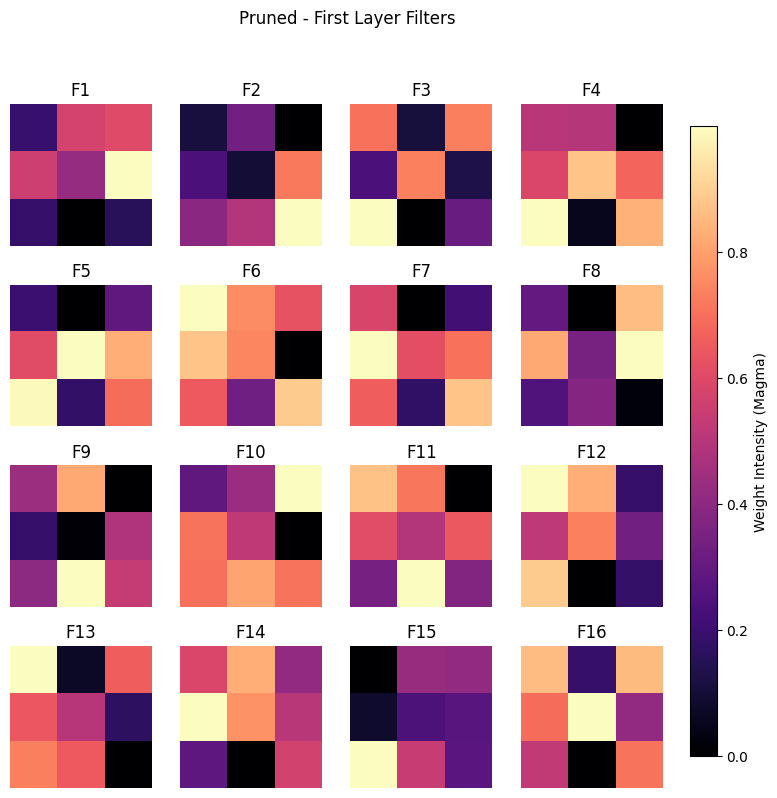

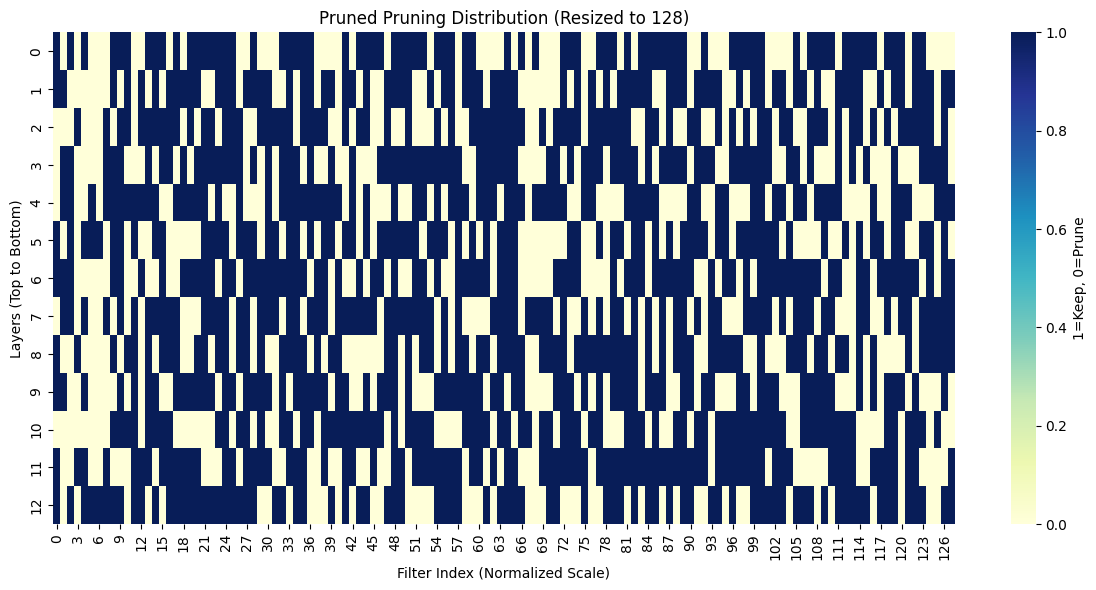

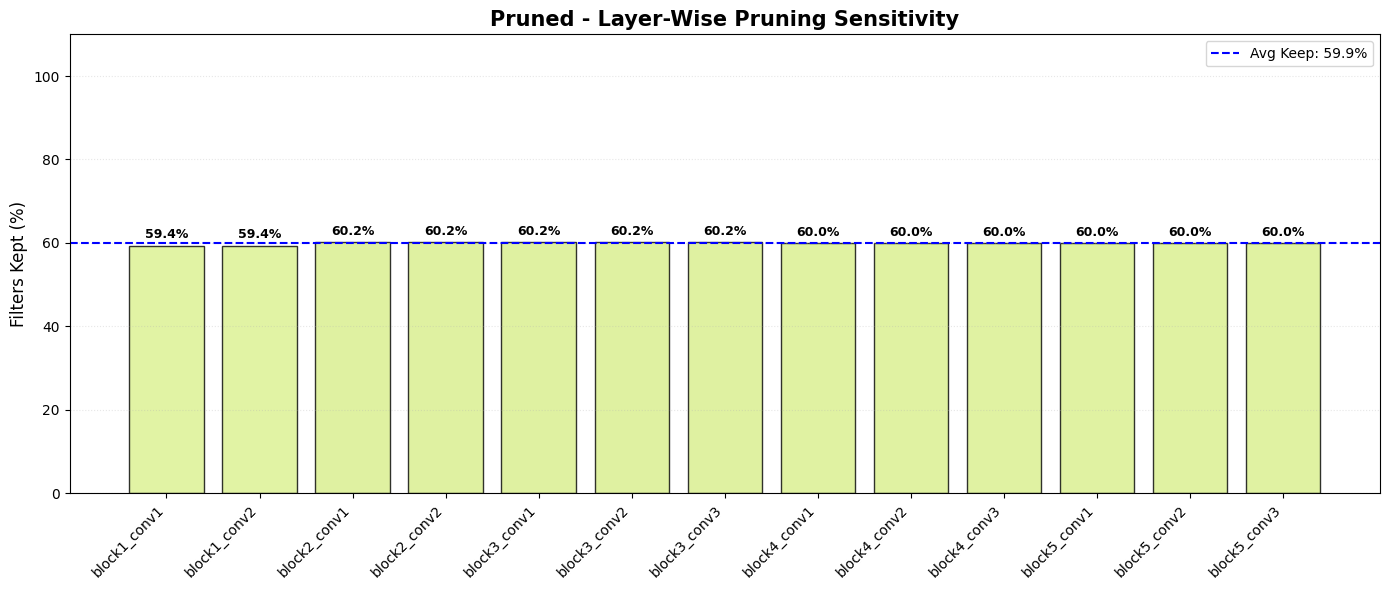

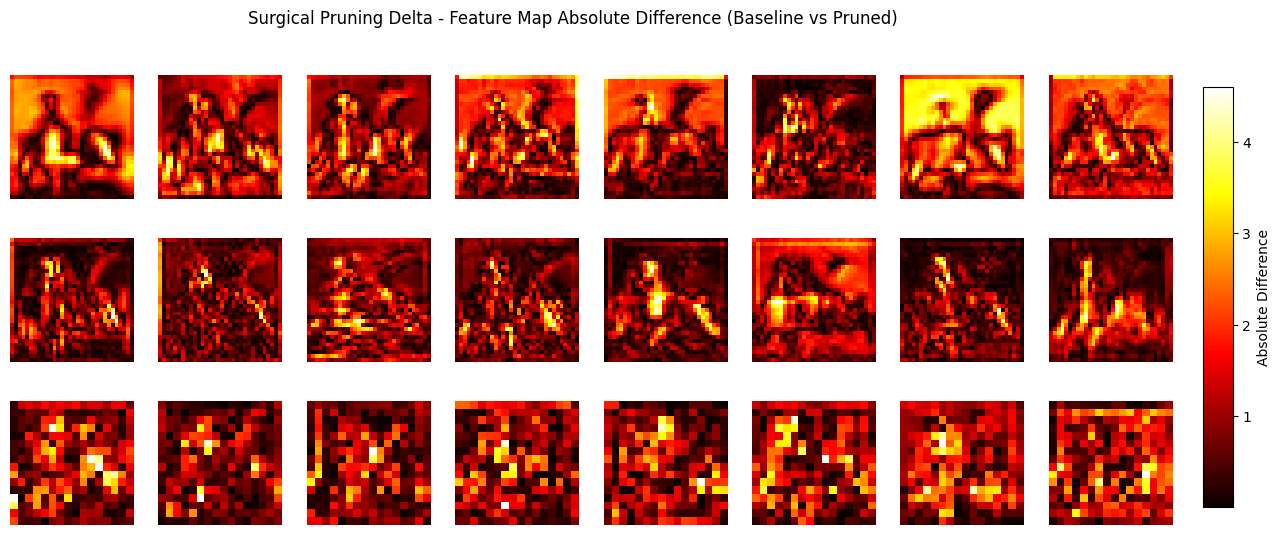

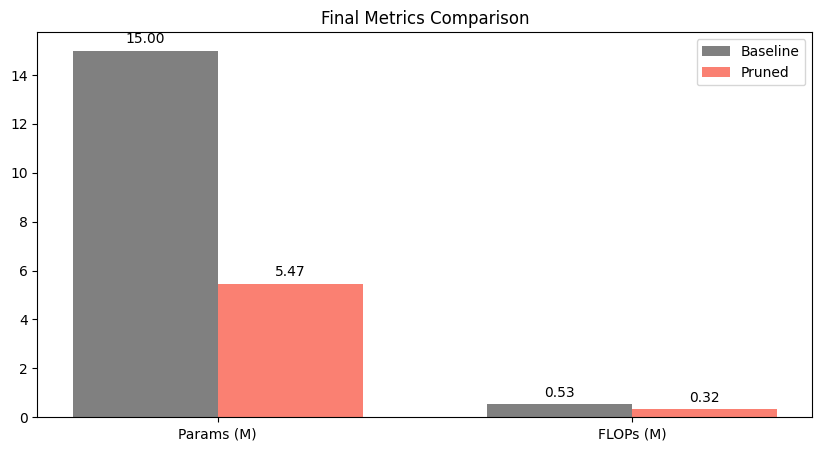

🚀 Business Impact: This model is theoretically 1.65x faster (FLOPs reduced by 39.3%).
✅ Pipeline Complete. Final Accuracy: 82.32%


In [5]:
!pip -q install thop seaborn tqdm matplotlib tensorflow keras-flops

import os, time, copy, abc, inspect
from pathlib import Path
import sys
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from typing import Dict, Tuple, Any, Callable
from datetime import datetime

# =========================================
# 1. DECORATORS & UTILS
# =========================================
def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        res = func(*args, **kwargs)
        print(f"⏱️ {func.__name__} took {time.time()-start:.2f}s")
        return res
    return wrapper

def logger(msg):
    def decorator(func):
        def wrapper(*args, **kwargs):
            print(f"\n--- {msg} ---")
            return func(*args, **kwargs)
        return wrapper
    return decorator

def _build_pruning_masks(score_map: Dict[str, np.ndarray], ratio: float, scope: str = "local") -> Dict[str, np.ndarray]:
    """
    Build boolean keep-masks from per-filter importance scores.

    Convention:
    - Higher score = more important = keep.
    - ratio is prune ratio.
    - scope:
      - local: threshold independently per layer
      - global: threshold across all layers together
    """
    if not (0.0 <= ratio < 1.0):
        raise ValueError("ratio must be in [0, 1).")
    if not score_map:
        return {}

    scope = scope.lower().strip()
    masks: Dict[str, np.ndarray] = {}

    if scope == "global":
        all_scores = np.concatenate([np.asarray(v).reshape(-1) for v in score_map.values()]).astype("float64")
        total = all_scores.size
        keep_total = max(1, int(round(total * (1.0 - ratio))))
        thresh = np.partition(all_scores, total - keep_total)[total - keep_total]

        for name, s in score_map.items():
            s = np.asarray(s, dtype="float64").reshape(-1)
            m = s >= thresh
            if m.sum() == 0:
                m[np.argmax(s)] = True
            masks[name] = m
    elif scope == "local":
        for name, s in score_map.items():
            s = np.asarray(s, dtype="float64").reshape(-1)
            keep = max(1, int(round(s.size * (1.0 - ratio))))
            idx = np.argpartition(s, -keep)[-keep:]
            m = np.zeros_like(s, dtype=bool)
            m[idx] = True
            masks[name] = m
    else:
        raise ValueError("scope must be 'local' or 'global'.")

    return masks

def _call_custom_score(score_fn: Callable[..., Any], kwargs: Dict[str, Any]):
    """Call user score_fn using only the args it declares."""
    sig = inspect.signature(score_fn)
    accepted = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return score_fn(**accepted)


_REMOTE_FS_WARNING_EMITTED = False


def resolve_model_dir(config: Dict[str, Any]) -> str:
    """Resolve checkpoint directory relative to project_dir and ensure it exists."""
    model_dir_cfg = str(config.get('model_dir', './saved_models'))
    project_dir_cfg = str(config.get('project_dir', os.getcwd()))

    model_dir = Path(model_dir_cfg).expanduser()
    if not model_dir.is_absolute():
        model_dir = Path(project_dir_cfg).expanduser() / model_dir

    model_dir = model_dir.resolve()
    model_dir.mkdir(parents=True, exist_ok=True)

    norm = str(model_dir).replace('\\', '/')
    in_colab_runtime = ('google.colab' in sys.modules) or ('COLAB_GPU' in os.environ)

    global _REMOTE_FS_WARNING_EMITTED
    if in_colab_runtime and norm.startswith('/content') and not _REMOTE_FS_WARNING_EMITTED:
        print("⚠️ You are on a remote Colab runtime, so checkpoints are saved to /content. Direct writes to C:/ local disk are not possible from this runtime.")
        _REMOTE_FS_WARNING_EMITTED = True

    return str(model_dir)


def export_checkpoint(path: str, config: Dict[str, Any]) -> None:
    """Optionally mirror/download checkpoints when running on remote runtimes."""
    src = Path(path)
    if not src.exists():
        return

    mirror_dir_cfg = config.get('checkpoint_mirror_dir', None)
    if mirror_dir_cfg:
        mirror_dir = Path(str(mirror_dir_cfg)).expanduser()
        if not mirror_dir.is_absolute():
            mirror_dir = Path(str(config.get('project_dir', os.getcwd()))).expanduser() / mirror_dir
        mirror_dir.mkdir(parents=True, exist_ok=True)
        dst = mirror_dir / src.name
        shutil.copy2(src, dst)
        print(f"📤 Mirrored checkpoint to: {dst.resolve()}")

    if bool(config.get('colab_auto_download_checkpoints', False)):
        try:
            from google.colab import files  # type: ignore
            files.download(str(src))
            print(f"📥 Download triggered for checkpoint: {src}")
        except Exception as e:
            print(f"⚠️ Could not trigger checkpoint download ({e}).")

# =========================================
# 2. ABSTRACT CORE
# =========================================
class FrameworkAdapter(abc.ABC):
    @abc.abstractmethod
    def get_model(self, model_type: str) -> Any: pass

    @abc.abstractmethod
    def train(self, model: Any, loader: Any, epochs: int, name: str): pass

    @abc.abstractmethod
    def evaluate(self, model: Any, loader: Any) -> float: pass

    @abc.abstractmethod
    def get_viz_data(self, model: Any, loader: Any, num_layers: int = 3) -> Dict[str, np.ndarray]: pass

    @abc.abstractmethod
    def get_stats(self, model: Any) -> Tuple[float, float]: pass

    @abc.abstractmethod
    def register_pruning_method(self, name: str, score_fn: Callable[..., Any]): pass

    @abc.abstractmethod
    def apply_pruning(self, model: Any, loader: Any, ratio: float, method: str) -> Tuple[Any, Dict[str, np.ndarray]]: pass

# =========================================
# 3. PYTORCH IMPLEMENTATION
# =========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, TensorDataset
from thop import profile

class TorchStructuralPruner:
    """V6-style structural channel surgery for Conv/BN/Linear dependencies."""

    def __init__(self, model):
        self.dependencies = self._trace(model)

    def _trace(self, model):
        dep = {}
        convs = [(n, m) for n, m in model.named_modules() if isinstance(m, nn.Conv2d)]
        names = [n for n, _ in convs]

        for i, (n, m) in enumerate(convs):
            dep[n] = {
                "siblings": [],
                "next": [names[i + 1]] if i + 1 < len(names) else [],
                "out_channels": m.out_channels,
            }

            # Match only immediate BN sibling (e.g., features.0 -> features.1), not all BN layers.
            parts = n.split('.')
            parent = '.'.join(parts[:-1])
            leaf = parts[-1]
            if leaf.isdigit():
                bn_name = f"{parent}.{int(leaf)+1}" if parent else str(int(leaf)+1)
                bn_mod = dict(model.named_modules()).get(bn_name, None)
                if isinstance(bn_mod, nn.BatchNorm2d):
                    dep[n]["siblings"].append(bn_name)

            if i == len(convs) - 1:
                linear_names = [nnm for nnm, mm in model.named_modules() if isinstance(mm, nn.Linear)]
                if linear_names:
                    dep[n]["next"] += [linear_names[0]]

        return dep

    def apply_masks(self, model, masks: Dict[str, torch.Tensor]):
        new_model = copy.deepcopy(model)
        for layer_name, keep_mask in masks.items():
            if layer_name not in self.dependencies:
                continue

            idx = torch.where(keep_mask)[0]
            if idx.numel() == 0:
                idx = torch.tensor([0], device=keep_mask.device)

            orig_out = self.dependencies[layer_name]["out_channels"]
            self._shrink(new_model, layer_name, idx, dim=0)

            for sib in self.dependencies[layer_name]["siblings"]:
                self._shrink(new_model, sib, idx, dim=0)

            for nxt in self.dependencies[layer_name]["next"]:
                self._shrink(new_model, nxt, idx, dim=1, source_channels=orig_out)

        return new_model

    def _shrink(self, model, name, idx, dim, source_channels=None):
        parts = name.split('.')
        curr = model
        for p in parts[:-1]:
            curr = getattr(curr, p)
        module = getattr(curr, parts[-1])

        if isinstance(module, nn.Conv2d):
            if dim == 0:
                module.weight = nn.Parameter(module.weight.data[idx])
                module.out_channels = int(len(idx))
                if module.bias is not None:
                    module.bias = nn.Parameter(module.bias.data[idx])
            else:
                module.weight = nn.Parameter(module.weight.data[:, idx])
                module.in_channels = int(len(idx))

        elif isinstance(module, nn.BatchNorm2d):
            module.weight = nn.Parameter(module.weight.data[idx])
            module.bias = nn.Parameter(module.bias.data[idx])
            module.running_mean = module.running_mean[idx]
            module.running_var = module.running_var[idx]
            module.num_features = int(len(idx))

        elif isinstance(module, nn.Linear):
            if dim == 1:
                if source_channels is None or source_channels == 0:
                    new_idx = idx
                else:
                    scale = module.in_features // source_channels
                    if scale <= 0:
                        scale = 1
                    new_idx = torch.cat([idx * scale + s for s in range(scale)]).sort()[0]
                module.weight = nn.Parameter(module.weight.data[:, new_idx])
                module.in_features = int(len(new_idx))


class PyTorchAdapter(FrameworkAdapter):
    def __init__(self, config):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.custom_methods: Dict[str, Callable[..., Any]] = {}

    def get_model(self, model_type):
        if model_type == 'vgg16':
            m = models.vgg16_bn(num_classes=10)
            m.avgpool = nn.AdaptiveAvgPool2d((1, 1))
            # Consistent classifier with Keras version
            m.classifier = nn.Sequential(
                nn.Linear(512, 512), 
                nn.ReLU(True), 
                nn.Linear(512, 10)
            )
            return m.to(self.device)

        if model_type in ('resnet18', 'resnet'):
            m = models.resnet18(num_classes=10)
            # CIFAR-friendly stem (as in V6)
            m.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
            m.maxpool = nn.Identity()
            # Consistent classifier
            m.fc = nn.Sequential(
                nn.Linear(512, 512),
                nn.ReLU(True),
                nn.Linear(512, 10)
            )
            return m.to(self.device)

        raise ValueError(f"Unsupported model_type for PyTorch: {model_type}")

    @timer
    def _loss_acc(self, model, loader):
        model.eval()
        crit = nn.CrossEntropyLoss()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)
                out = model(x)
                loss = crit(out, y)
                total_loss += float(loss.item()) * y.size(0)
                correct += int((out.argmax(1) == y).sum().item())
                total += int(y.size(0))
        avg_loss = total_loss / max(total, 1)
        acc = 100.0 * correct / max(total, 1)
        return avg_loss, acc

    @timer
    def train(self, model, loader, epochs, name, val_loader=None):
        model_dir = str(self.config.get('model_dir', ''))
        if not model_dir:
            model_dir = resolve_model_dir(self.config)
            self.config['model_dir'] = model_dir
        path = os.path.abspath(os.path.join(model_dir, f"{self.config['name']}_{name}.pth"))

        if os.path.exists(path) and not self.config['force_retrain']:
            model.load_state_dict(torch.load(path, map_location=self.device))
            print(f"📂 Loaded cached model for {name} from {path}")
            # Return empty history so caller can continue safely.
            return {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        # V6-style Research Setup: Adam 3e-4, CrossEntropy
        lr = float(self.config.get('lr', 3e-4))
        opt = optim.Adam(model.parameters(), lr=lr)
        crit = nn.CrossEntropyLoss()
        hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        for e in range(epochs):
            model.train()
            total_loss, correct, total = 0.0, 0, 0
            for x, y in tqdm(loader, desc=f"{name} E{e+1}", leave=False):
                x, y = x.to(self.device), y.to(self.device)
                opt.zero_grad()
                out = model(x)
                loss = crit(out, y)
                loss.backward()
                opt.step()

                total_loss += float(loss.item()) * y.size(0)
                correct += int((out.argmax(1) == y).sum().item())
                total += int(y.size(0))

            train_loss = total_loss / max(total, 1)
            train_acc = 100.0 * correct / max(total, 1)
            hist['train_loss'].append(train_loss)
            hist['train_acc'].append(train_acc)

            if val_loader is not None:
                val_loss, val_acc = self._loss_acc(model, val_loader)
                hist['val_loss'].append(val_loss)
                hist['val_acc'].append(val_acc)
                print(f"{name} Epoch {e+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | val_loss={val_loss:.4f} val_acc={val_acc:.2f}%")
            else:
                print(f"{name} Epoch {e+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.2f}%")

        torch.save(model.state_dict(), path)
        print(f"💾 Saved PyTorch model for {name} to {path}")
        export_checkpoint(path, self.config)
        return hist

    def evaluate(self, model, loader):
        _, acc = self._loss_acc(model, loader)
        return acc

    def get_viz_data(self, model, loader, num_layers=3):
        model.eval(); acts = {}; convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
        hooks = [layer.register_forward_hook(lambda m, i, o, n=f"l{idx}": acts.update({n: o.detach()}))
                 for idx, layer in enumerate(convs[:num_layers])]
        x, _ = next(iter(loader)); x = x[:1].to(self.device)
        with torch.no_grad(): model(x)
        for h in hooks: h.remove()
        return {
            "activations": [v[0].cpu().numpy() for v in acts.values()],
            "filters": convs[0].weight.data.cpu().numpy()
        }

    def get_stats(self, model):
        m_cp = copy.deepcopy(model).cpu().eval()
        # Use a dummy input to trigger shape inference if needed
        f, p = profile(m_cp, inputs=(torch.randn(1, 3, 32, 32),), verbose=False)
        return float(f), float(p)

    def register_pruning_method(self, name: str, score_fn: Callable[..., Any]):
        if not callable(score_fn):
            raise TypeError("score_fn must be callable")
        self.custom_methods[name] = score_fn

    def _weight_score(self, method: str, layer: nn.Conv2d) -> torch.Tensor:
        w = layer.weight.data
        method = method.lower().strip()
        if method in ("l1", "l1_norm"):
            return w.abs().mean(dim=(1, 2, 3))
        if method in ("l2", "l2_norm"):
            return torch.sqrt((w ** 2).mean(dim=(1, 2, 3)) + 1e-12)
        if method in ("random", "rand"):
            return torch.rand(w.shape[0], device=w.device)
        return None

    def _activation_or_taylor_scores(self, model, loader, method: str) -> Dict[str, np.ndarray]:
        """Research-valid activation/gradient methods: mean_abs_act, apoz, variance_act, taylor."""
        convs = [(n, m) for n, m in model.named_modules() if isinstance(m, nn.Conv2d)]
        if not convs:
            return {}

        method = method.lower().strip()
        batches = int(self.config.get("prune_batches", 3))
        batches = max(1, batches)

        model.eval()

        acc = {}
        cnt = {}
        sum1 = {}
        sum2 = {}
        acts_curr = {}

        for name, layer in convs:
            out_ch = layer.weight.shape[0]
            acc[name] = torch.zeros(out_ch, device=self.device)
            cnt[name] = 0
            if method == "variance_act":
                sum1[name] = torch.zeros(out_ch, device=self.device)
                sum2[name] = torch.zeros(out_ch, device=self.device)

        hooks = []

        def f_hook(name):
            def hook(_m, _i, o):
                a = o.detach()
                elems = a.shape[0] * a.shape[2] * a.shape[3]
                if method == "mean_abs_act":
                    acc[name] += a.abs().sum(dim=(0, 2, 3))
                    cnt[name] += elems
                elif method == "apoz":
                    acc[name] += (a == 0).float().sum(dim=(0, 2, 3))
                    cnt[name] += elems
                elif method == "variance_act":
                    sum1[name] += a.sum(dim=(0, 2, 3))
                    sum2[name] += (a ** 2).sum(dim=(0, 2, 3))
                    cnt[name] += elems
                elif method == "taylor":
                    acts_curr[name] = a
            return hook

        def b_hook(name):
            def hook(_m, _gin, gout):
                if method != "taylor":
                    return
                g = gout[0].detach()
                a = acts_curr.get(name)
                if a is None:
                    return
                elems = a.shape[0] * a.shape[2] * a.shape[3]
                acc[name] += (a * g).abs().sum(dim=(0, 2, 3))
                cnt[name] += elems
            return hook

        for name, layer in convs:
            hooks.append(layer.register_forward_hook(f_hook(name)))
            if method == "taylor":
                hooks.append(layer.register_full_backward_hook(b_hook(name)))

        for bi, (x, y) in enumerate(loader):
            if bi >= batches:
                break
            x = x.to(self.device)
            y = y.to(self.device)

            model.zero_grad(set_to_none=True)
            out = model(x)
            if method == "taylor":
                loss = F.cross_entropy(out, y)
                loss.backward()

            acts_curr.clear()

        for h in hooks:
            h.remove()

        scores = {}
        for name, _layer in convs:
            c = max(cnt[name], 1)
            if method == "mean_abs_act":
                s = acc[name] / c
            elif method == "apoz":
                # APoZ itself is prune-score (higher prune); convert to keep-score.
                apoz = acc[name] / c
                s = 1.0 - apoz
            elif method == "variance_act":
                mean = sum1[name] / c
                var = (sum2[name] / c) - (mean ** 2)
                s = torch.clamp(var, min=0.0)
            elif method == "taylor":
                s = acc[name] / c
            else:
                raise ValueError(f"Unsupported activation method: {method}")
            scores[name] = s.detach().cpu().numpy()

        return scores

    def apply_pruning(self, model, loader, ratio, method):
        convs = [(n, m) for n, m in model.named_modules() if isinstance(m, nn.Conv2d)]
        if not convs:
            return model, {}

        method_norm = method.lower().strip()
        score_map: Dict[str, np.ndarray] = {}

        if method in self.custom_methods:
            for name, layer in convs:
                raw = _call_custom_score(
                    self.custom_methods[method],
                    {
                        "layer_name": name,
                        "layer": layer,
                        "model": model,
                        "loader": loader,
                        "device": self.device,
                    },
                )
                s = torch.as_tensor(raw, device=self.device, dtype=torch.float32).flatten()
                if s.numel() != layer.weight.shape[0]:
                    raise ValueError(
                        f"Custom method '{method}' returned {s.numel()} scores for layer '{name}' "
                        f"but expected {layer.weight.shape[0]} (one per output filter)."
                    )
                score_map[name] = s.detach().cpu().numpy()
        elif method_norm in ("mean_abs_act", "apoz", "variance_act", "taylor"):
            score_map = self._activation_or_taylor_scores(model, loader, method_norm)
        else:
            for name, layer in convs:
                s = self._weight_score(method_norm, layer)
                if s is None:
                    available = sorted(list(self.custom_methods.keys()) + [
                        "l1_norm", "l2_norm", "random", "mean_abs_act", "apoz", "variance_act", "taylor"
                    ])
                    raise ValueError(
                        f"Unknown pruning method '{method}'. "
                        f"Use one of {available} or register custom math with register_pruning_method(...)."
                    )
                score_map[name] = s.detach().cpu().numpy()

        scope = self.config.get("scope", "local")
        masks = _build_pruning_masks(score_map, ratio=ratio, scope=scope)

        # Structural surgery (V6-style): robustly applied for VGG-like sequential stacks.
        model_type = str(self.config.get("model_type", "vgg16")).lower()
        if model_type == "vgg16":
            torch_masks = {
                n: torch.as_tensor(m, device=self.device, dtype=torch.bool)
                for n, m in masks.items()
                if n in dict(convs)
            }
            pruned_model = TorchStructuralPruner(model).apply_masks(model, torch_masks)
        else:
            # Keep feature available for non-VGG models while avoiding unsafe graph surgery.
            print("⚠️ Structural channel surgery is currently validated for 'vgg16'. "
                  "For this architecture, returning original model + research-valid masks.")
            pruned_model = model

        print(f"✂️ PyTorch pruning masks built with method='{method}', scope='{scope}', ratio={ratio}")
        return pruned_model, masks

# =========================================
# 4. KERAS IMPLEMENTATION
# =========================================
import tensorflow as tf
from tensorflow.keras import layers, models as k_models

def build_vgg16_bn_keras(input_shape=(32, 32, 3), num_classes=10):
    """
    Build VGG16 with Batch Normalization to match PyTorch's vgg16_bn.
    Uses he_normal initialization for better convergence from scratch.
    """
    img_input = layers.Input(shape=input_shape)
    init = 'he_normal'

    def conv_block(x, filters, num_convs, name_prefix):
        for i in range(num_convs):
            x = layers.Conv2D(filters, 3, padding='same', kernel_initializer=init, name=f"{name_prefix}_conv{i+1}")(x)
            x = layers.BatchNormalization(name=f"{name_prefix}_bn{i+1}")(x)
            x = layers.Activation('relu', name=f"{name_prefix}_relu{i+1}")(x)
        x = layers.MaxPooling2D(2, strides=2, name=f"{name_prefix}_pool")(x)
        return x

    x = conv_block(img_input, 64, 2, 'block1')
    x = conv_block(x, 128, 2, 'block2')
    x = conv_block(x, 256, 3, 'block3')
    x = conv_block(x, 512, 3, 'block4')
    x = conv_block(x, 512, 3, 'block5')

    x = layers.GlobalAveragePooling2D(name='avgpool')(x)
    x = layers.Dense(512, activation='relu', kernel_initializer=init, name='fc1')(x)
    x = layers.Dense(num_classes, activation='softmax', kernel_initializer=init, name='predictions')(x)

    return k_models.Model(img_input, x, name='vgg16_bn')

class KerasEpochLogger(tf.keras.callbacks.Callback):
    def __init__(self, run_name: str):
        super().__init__()
        self.run_name = run_name

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        tr_loss = float(logs.get('loss', 0.0))
        tr_acc = 100.0 * float(logs.get('accuracy', logs.get('acc', 0.0)))
        msg = f"{self.run_name} Epoch {epoch + 1}/{self.params.get('epochs', '?')} | train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}%"

        if 'val_loss' in logs:
            va_loss = float(logs.get('val_loss', 0.0))
            va_acc = 100.0 * float(logs.get('val_accuracy', logs.get('val_acc', 0.0)))
            msg += f" | val_loss={va_loss:.4f} val_acc={va_acc:.2f}%"

        print(msg, flush=True)


class KerasAdapter(FrameworkAdapter):
    def __init__(self, config):
        self.config = config
        self.custom_methods: Dict[str, Callable[..., Any]] = {}

    def get_model(self, model_type):
        model_type = str(model_type).lower().strip()
        keras_lr = float(self.config.get('keras_lr', self.config.get('lr', 3e-4)))
        
        if model_type == 'vgg16':
            # Use custom VGG16 with BatchNorm to match PyTorch vgg16_bn
            m = build_vgg16_bn_keras(input_shape=(32, 32, 3), num_classes=10)
            m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=keras_lr),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
            return m

        if model_type in ('resnet50', 'resnet'):
            # For ResNet50, we still use the application but ensure consistent classifier
            weights_cfg = str(self.config.get('keras_weights', 'none')).lower().strip()
            weights = None if weights_cfg in ('none', 'null', '') else weights_cfg
            
            base = tf.keras.applications.ResNet50(include_top=False, weights=weights, input_shape=(32, 32, 3))
            x = layers.GlobalAveragePooling2D()(base.output)
            x = layers.Dense(512, activation='relu')(x)
            out = layers.Dense(10, activation='softmax')(x)
            m = k_models.Model(inputs=base.input, outputs=out)
            m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=keras_lr),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
            return m

        raise ValueError(f"Unsupported model_type for Keras: {model_type}")

    def _eval_loss_acc(self, model, loader):
        if loader is None:
            return None, None
        vals = model.evaluate(loader, verbose=0)
        if isinstance(vals, (list, tuple)) and len(vals) >= 2:
            return float(vals[0]), 100.0 * float(vals[1])
        return None, None

    @timer
    def train(self, model, loader, epochs, name, val_loader=None):
        model_dir = str(self.config.get('model_dir', ''))
        if not model_dir:
            model_dir = resolve_model_dir(self.config)
            self.config['model_dir'] = model_dir
        filename = f"{self.config['name']}_{self.config.get('model_type', 'model')}_{name}.weights.h5"
        path = os.path.abspath(os.path.join(model_dir, filename))

        if os.path.exists(path) and not self.config['force_retrain']:
            try:
                model.load_weights(path)
                print(f"📂 Loaded cached weights for {name} from {path}")
                tl, ta = self._eval_loss_acc(model, loader)
                vl, va = self._eval_loss_acc(model, val_loader)
                hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
                if tl is not None:
                    hist['train_loss'].append(tl); hist['train_acc'].append(ta)
                if vl is not None:
                    hist['val_loss'].append(vl); hist['val_acc'].append(va)
                return hist
            except Exception as e:
                print(f"⚠️ Failed to load cached weights ({e}); retraining {name}.")

        callbacks = [KerasEpochLogger(name)]
        h = model.fit(loader, validation_data=val_loader, epochs=epochs, verbose=0, callbacks=callbacks)
        hist = {
            'train_loss': list(h.history.get('loss', [])),
            'train_acc': [100.0 * float(x) for x in h.history.get('accuracy', h.history.get('acc', []))],
            'val_loss': list(h.history.get('val_loss', [])),
            'val_acc': [100.0 * float(x) for x in h.history.get('val_accuracy', h.history.get('val_acc', []))],
        }

        model.save_weights(path)
        print(f"💾 Saved Keras weights for {name} to {path}")
        export_checkpoint(path, self.config)
        return hist

    def evaluate(self, model, loader):
        return model.evaluate(loader, verbose=0)[1] * 100

    def get_viz_data(self, model, loader, num_layers=3):
        conv_layers = [l for l in model.layers if isinstance(l, layers.Conv2D)]
        model_input = model.inputs[0] if getattr(model, "inputs", None) else model.input
        viz_model = k_models.Model(inputs=model_input, outputs=[l.output for l in conv_layers[:num_layers]])
        x, _ = next(iter(loader)); x = x[:1]
        outputs = viz_model.predict(x, verbose=0)
        if num_layers == 1:
            outputs = [outputs]
        return {
            "activations": [o[0].transpose(2, 0, 1) for o in outputs],
            "filters": conv_layers[0].get_weights()[0].transpose(3, 2, 0, 1)
        }

    def _estimate_flops(self, model):
        """
        Analytical FLOPs estimate for Keras models (Conv2D and Dense).
        Correctly handles pruned shapes by looking at weights.
        """
        flops = 0.0
        for l in model.layers:
            if isinstance(l, layers.Conv2D):
                try:
                    # kernel shape: (kh, kw, in_ch, out_ch)
                    w = l.get_weights()[0]
                    kh, kw, cin, cout = w.shape
                    out_shape = l.output_shape
                    h, w_out = out_shape[1], out_shape[2]
                    # FLOPs = 2 * H * W * Cin * Cout * Kh * Kw
                    flops += 2.0 * h * w_out * cin * cout * kh * kw
                except Exception:
                    pass
            elif isinstance(l, layers.Dense):
                try:
                    w = l.get_weights()[0]
                    cin, cout = w.shape
                    flops += 2.0 * cin * cout
                except Exception:
                    pass
        return float(flops)

    def get_stats(self, model):
        # keras_flops often fails in colab/new-TF due to registration errors.
        # We use our analytical estimate as primary for stability.
        est = self._estimate_flops(model)
        params = float(model.count_params())
        return est, params

    def register_pruning_method(self, name: str, score_fn: Callable[..., Any]):
        if not callable(score_fn):
            raise TypeError("score_fn must be callable")
        self.custom_methods[name] = score_fn

    def _weight_score(self, method: str, layer: tf.keras.layers.Conv2D) -> np.ndarray:
        w = layer.get_weights()[0]  # (kh, kw, in_ch, out_ch)
        method = method.lower().strip()
        if method in ("l1", "l1_norm"):
            return np.mean(np.abs(w), axis=(0, 1, 2))
        if method in ("l2", "l2_norm"):
            return np.sqrt(np.mean(np.square(w), axis=(0, 1, 2)) + 1e-12)
        if method in ("random", "rand"):
            return np.random.rand(w.shape[-1])
        return None

    def _activation_or_taylor_scores(self, model, loader, method: str) -> Dict[str, np.ndarray]:
        conv_layers = [(l.name, l) for l in model.layers if isinstance(l, layers.Conv2D)]
        if not conv_layers:
            return {}

        batches = int(self.config.get("prune_batches", 3))
        batches = max(1, batches)

        model_input = model.inputs[0] if getattr(model, "inputs", None) else model.input
        out_tensors = [l.output for _, l in conv_layers] + [model.output]
        probe_model = k_models.Model(inputs=model_input, outputs=out_tensors)

        acc = {n: np.zeros(l.get_weights()[0].shape[-1], dtype=np.float64) for n, l in conv_layers}
        cnt = {n: 0 for n, _ in conv_layers}
        sum1 = {n: np.zeros_like(acc[n]) for n, _ in conv_layers}
        sum2 = {n: np.zeros_like(acc[n]) for n, _ in conv_layers}

        it = iter(loader)
        for bi in range(batches):
            try:
                x, y = next(it)
            except StopIteration:
                break

            if method == "taylor":
                with tf.GradientTape() as tape:
                    outs = probe_model(x, training=False)
                    conv_outs = outs[:-1]
                    logits = outs[-1]
                    y_flat = tf.reshape(y, [-1])
                    loss = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_flat, logits))
                grads = tape.gradient(loss, conv_outs)

                for (name, _layer), a, g in zip(conv_layers, conv_outs, grads):
                    a_np = a.numpy()
                    g_np = g.numpy()
                    elems = a_np.shape[0] * a_np.shape[1] * a_np.shape[2]
                    acc[name] += np.abs(a_np * g_np).sum(axis=(0, 1, 2))
                    cnt[name] += elems
            else:
                outs = probe_model(x, training=False)
                conv_outs = outs[:-1]
                for (name, _layer), a in zip(conv_layers, conv_outs):
                    a_np = a.numpy()
                    elems = a_np.shape[0] * a_np.shape[1] * a_np.shape[2]
                    if method == "mean_abs_act":
                        acc[name] += np.abs(a_np).sum(axis=(0, 1, 2))
                    elif method == "apoz":
                        acc[name] += (a_np == 0).sum(axis=(0, 1, 2))
                    elif method == "variance_act":
                        sum1[name] += a_np.sum(axis=(0, 1, 2))
                        sum2[name] += (a_np ** 2).sum(axis=(0, 1, 2))
                    else:
                        raise ValueError(f"Unsupported activation method: {method}")
                    cnt[name] += elems

        score_map = {}
        for name, _layer in conv_layers:
            c = max(cnt[name], 1)
            if method == "mean_abs_act":
                s = acc[name] / c
            elif method == "apoz":
                s = 1.0 - (acc[name] / c)
            elif method == "variance_act":
                mean = sum1[name] / c
                s = np.maximum((sum2[name] / c) - (mean ** 2), 0.0)
            elif method == "taylor":
                s = acc[name] / c
            else:
                raise ValueError(f"Unsupported activation method: {method}")
            score_map[name] = np.asarray(s, dtype=np.float64).reshape(-1)

        return score_map

    def _apply_structural_pruning(self, model, masks: Dict[str, np.ndarray]):
        """
        Structural channel pruning for VGG-like Conv2D stacks in Keras.
        Physically removes filters/channels and rebuilds architecture.
        """
        try:
            inputs = tf.keras.Input(shape=model.input_shape[1:])
            x = inputs
            prev_keep = np.arange(model.input_shape[-1], dtype=int)
            
            for layer in model.layers:
                if isinstance(layer, layers.InputLayer): continue
                
                cfg = layer.get_config().copy()
                if isinstance(layer, layers.Conv2D):
                    mask = np.asarray(masks.get(layer.name, np.ones(layer.filters, dtype=bool))).astype(bool)
                    keep_out = np.where(mask)[0]
                    if keep_out.size == 0: keep_out = np.array([0], dtype=int)
                    
                    cfg['filters'] = int(len(keep_out))
                    new_layer = layers.Conv2D.from_config(cfg)
                    x = new_layer(x)
                    
                    w = layer.get_weights()
                    # Slice input channels (dim 2) and output filters (dim 3)
                    k = w[0][:, :, prev_keep, :][:, :, :, keep_out]
                    new_w = [k]
                    if len(w) > 1: new_w.append(w[1][keep_out])
                    new_layer.set_weights(new_w)
                    prev_keep = keep_out
                    
                elif isinstance(layer, layers.BatchNormalization):
                    new_layer = layers.BatchNormalization.from_config(cfg)
                    x = new_layer(x)
                    w = layer.get_weights() # [gamma, beta, mean, var]
                    new_w = [v[prev_keep] for v in w]
                    new_layer.set_weights(new_w)
                    
                elif isinstance(layer, layers.Dense):
                    new_layer = layers.Dense.from_config(cfg)
                    # We must build the layer with the new input shape before setting weights
                    x = new_layer(x)
                    w = layer.get_weights()
                    k = w[0][prev_keep, :]
                    new_layer.set_weights([k, w[1]])
                    prev_keep = np.arange(layer.units, dtype=int)
                    
                else:
                    new_layer = layer.__class__.from_config(cfg)
                    x = new_layer(x)
                    if layer.get_weights():
                        new_layer.set_weights(layer.get_weights())
            
            new_model = tf.keras.Model(inputs=inputs, outputs=x, name=f"{model.name}_pruned")
            new_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=float(self.config.get('lr', 3e-4))),
                              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
            return new_model
        except Exception as e:
            print(f"⚠️ Keras structural rebuild failed: {e}")
            return model

    def apply_pruning(self, model, loader, ratio, method):
        conv_layers = [(l.name, l) for l in model.layers if isinstance(l, layers.Conv2D)]
        if not conv_layers:
            return model, {}

        method_norm = method.lower().strip()
        score_map: Dict[str, np.ndarray] = {}

        if method in self.custom_methods:
            for name, layer in conv_layers:
                raw = _call_custom_score(
                    self.custom_methods[method],
                    {
                        "layer_name": name,
                        "layer": layer,
                        "model": model,
                        "loader": loader,
                    },
                )
                s = np.asarray(raw, dtype=np.float64).reshape(-1)
                expected = layer.get_weights()[0].shape[-1]
                if s.size != expected:
                    raise ValueError(
                        f"Custom method '{method}' returned {s.size} scores for layer '{name}' "
                        f"but expected {expected} (one per output filter)."
                    )
                score_map[name] = s
        elif method_norm in ("mean_abs_act", "apoz", "variance_act", "taylor"):
            score_map = self._activation_or_taylor_scores(model, loader, method_norm)
        else:
            for name, layer in conv_layers:
                s = self._weight_score(method_norm, layer)
                if s is None:
                    available = sorted(list(self.custom_methods.keys()) + [
                        "l1_norm", "l2_norm", "random", "mean_abs_act", "apoz", "variance_act", "taylor"
                    ])
                    raise ValueError(
                        f"Unknown pruning method '{method}'. "
                        f"Use one of {available} or register custom math with register_pruning_method(...)."
                    )
                score_map[name] = np.asarray(s, dtype=np.float64).reshape(-1)

        scope = self.config.get("scope", "local")
        masks = _build_pruning_masks(score_map, ratio=ratio, scope=scope)

        # Structural rebuild path currently validated for VGG-like stacks.
        model_type = str(self.config.get("model_type", "vgg16")).lower()
        if model_type == "vgg16":
            try:
                pruned_model = self._apply_structural_pruning(model, masks)
            except Exception as e:
                print(f"⚠️ Keras structural rebuild failed ({e}); returning original model with masks.")
                pruned_model = model
        else:
            print("⚠️ Keras structural rebuild is currently validated for 'vgg16'. "
                  "For this architecture, returning original model + research-valid masks.")
            pruned_model = model

        print(f"✂️ Keras pruning masks built with method='{method}', scope='{scope}', ratio={ratio}")
        return pruned_model, masks

# =========================================
# 5. STANDARDIZED VISUALIZATION
# =========================================
def plot_layer_sensitivity(masks: Dict[str, np.ndarray], title_prefix: str):
    if not masks:
        return
    layers_list = sorted(masks.keys())
    keep_ratios = [float(np.mean(masks[l]) * 100) for l in layers_list]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    # Green for kept, Red for pruned. Use a colormap mapping 0-100 to Red-Green
    colors = plt.cm.RdYlGn(np.array(keep_ratios) / 100.0)
    bars = ax.bar(layers_list, keep_ratios, color=colors, alpha=0.8, edgecolor='black')
    
    ax.axhline(y=np.mean(keep_ratios), color='blue', linestyle='--', label=f'Avg Keep: {np.mean(keep_ratios):.1f}%')
    ax.set_title(f"{title_prefix} - Layer-Wise Pruning Sensitivity", fontsize=15, fontweight='bold')
    ax.set_ylabel("Filters Kept (%)", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    ax.set_ylim(0, 110)
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    
    # Value labels
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 1, f'{h:.1f}%', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def plot_feature_map_delta(base_viz, pruned_viz, title_prefix="Surgical Pruning Delta"):
    """
    Visualize the 'Representation Error' introduced by pruning.
    Bright spots show where the pruned model's feature maps differ from the baseline.
    A dark delta map visually proves the pruning was 'surgical' and behaviorally consistent.
    """
    b_acts = base_viz['activations']
    p_acts = pruned_viz['activations']
    num_l = min(len(b_acts), len(p_acts))
    fig, axes = plt.subplots(num_l, 8, figsize=(15, 2*num_l))
    if num_l == 1:
        axes = np.expand_dims(axes, axis=0)
    for i in range(num_l):
        b_layer = b_acts[i]
        p_layer = p_acts[i]
        # The shapes might differ if pruned, we compare up to the min available filters
        min_f = min(b_layer.shape[0], p_layer.shape[0], 8)
        for j in range(8):
            ax = axes[i, j]
            if j < min_f:
                delta = np.abs(b_layer[j] - p_layer[j])
                im = ax.imshow(delta, cmap='hot')
            else:
                ax.imshow(np.zeros((8,8)), cmap='hot')
            ax.axis('off')
            if j == 0: ax.set_ylabel(f"Layer {i+1}", rotation=0, labelpad=40, size='large')

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Absolute Difference')
    plt.suptitle(f"{title_prefix} - Feature Map Absolute Difference (Baseline vs Pruned)")
    plt.show()

def visualize_all_layers_heatmaps(masks: Dict[str, np.ndarray], title: str = "Filter Distribution"):
    """
    Visualize the distribution of kept vs pruned filters across all layers.
    Filter indices are resized to 128 for a uniform surgical view.
    """
    if not masks:
        print("⚠️ No masks provided for heatmap visualization.")
        return

    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Resize all masks to 128 for uniform heatmap
    sorted_layers = sorted(masks.keys())
    p_data = [np.resize(np.asarray(masks[ln]).astype(float), (128,)) for ln in sorted_layers]
    
    sns.heatmap(p_data, cmap="YlGnBu", ax=ax, vmin=0, vmax=1, cbar_kws={'label': '1=Keep, 0=Prune'})
    
    ax.set_title(f"{title} (Resized to 128)")
    ax.set_ylabel("Layers (Top to Bottom)")
    ax.set_xlabel("Filter Index (Normalized Scale)")
    
    plt.tight_layout()
    plt.show()

def plot_viz_suite(viz_data, title_prefix, masks=None):
    acts = viz_data['activations']
    num_l = len(acts)
    fig, axes = plt.subplots(num_l, 8, figsize=(15, 2*num_l))
    if num_l == 1:
        axes = np.expand_dims(axes, axis=0)
    for i in range(num_l):
        layer_acts = acts[i]
        for j in range(8):
            ax = axes[i, j]
            im = ax.imshow(layer_acts[j] if j < layer_acts.shape[0] else np.zeros((8,8)), cmap='viridis')
            ax.axis('off')
            if j == 0: ax.set_ylabel(f"Layer {i+1}", rotation=0, labelpad=40, size='large')

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Activation Level')
    plt.suptitle(f"{title_prefix} - First {num_l} Layers Feature Maps")
    plt.show()

    # Visualize first layer filters
    weights = viz_data['filters']
    n_filters = min(16, weights.shape[0])
    fig, axes = plt.subplots(int(np.ceil(n_filters/4)), 4, figsize=(9, 9))
    im = None
    for i in range(n_filters):
        ax = axes[i//4, i%4]
        f = weights[i, 0]
        im = ax.imshow((f - f.min())/(f.max()-f.min()+1e-5), cmap='magma')
        ax.axis('off')
        ax.set_title(f"F{i+1}")
    
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Weight Intensity (Magma)')
    plt.suptitle(f"{title_prefix} - First Layer Filters")
    plt.show()

    if masks is not None:
        visualize_all_layers_heatmaps(masks, f"{title_prefix} Pruning Distribution")
        plot_layer_sensitivity(masks, title_prefix)


def plot_comparison(b_stats, p_stats):
    labels = ['Params (M)', 'FLOPs (M)']
    b = [b_stats[1]/1e6, b_stats[0]/1e6]
    p = [p_stats[1]/1e6, p_stats[0]/1e6]
    x = np.arange(len(labels)); w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    r1 = ax.bar(x - w/2, b, w, label='Baseline', color='gray')
    r2 = ax.bar(x + w/2, p, w, label='Pruned', color='salmon')
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.legend(); ax.set_title("Final Metrics Comparison")
    for r in [r1, r2]: ax.bar_label(r, padding=3, fmt='%.2f')
    plt.show()
    
    reduction_pct = (1 - p_stats[0]/b_stats[0]) * 100
    speedup = b_stats[0] / p_stats[0]
    print(f"🚀 Business Impact: This model is theoretically {speedup:.2f}x faster (FLOPs reduced by {reduction_pct:.1f}%).")


def plot_training_history(history, title="Training History"):
    # Skip if history is empty or contains no data (e.g. model loaded from cache)
    if not history or not history.get('train_loss') or len(history['train_loss']) == 0:
        print(f"ℹ️ Training history for '{title}' is empty (likely model was loaded from cache). Skipping plot.")
        return

    epochs = np.arange(1, len(history.get('train_loss', [])) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    if len(history.get('train_acc', [])):
        ax1.plot(epochs, history['train_acc'], label='Train Acc')
    if len(history.get('val_acc', [])):
        ax1.plot(np.arange(1, len(history['val_acc']) + 1), history['val_acc'], label='Val Acc')
    ax1.set_title(f"{title} - Accuracy")
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.grid(True)
    ax1.legend()

    if len(history.get('train_loss', [])):
        ax2.plot(epochs, history['train_loss'], label='Train Loss')
    if len(history.get('val_loss', [])):
        ax2.plot(np.arange(1, len(history['val_loss']) + 1), history['val_loss'], label='Val Loss')
    ax2.set_title(f"{title} - Loss")
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# =========================================
# 6. ORCHESTRATOR
# =========================================
class PruningOrchestrator:
    def __init__(self, adapter):
        self.adapter = adapter
        self.config = adapter.config

    @logger("Starting Pruning Pipeline")
    def run(self, loader, val_loader=None, model=None):
        if model is None:
            model = self.adapter.get_model(self.config['model_type'])

        print("🚀 Training Baseline...")
        h_base = self.adapter.train(model, loader, self.config['epochs'], "Baseline", val_loader=val_loader)
        plot_training_history(h_base, "Baseline")

        print("🖼️ Visualizing Baseline (Post-Training)...")
        b_viz_data = self.adapter.get_viz_data(model, loader)
        plot_viz_suite(b_viz_data, "Baseline")

        b_stats = self.adapter.get_stats(model)
        base_acc = self.adapter.evaluate(model, val_loader if val_loader is not None else loader)
        print(f"📊 Baseline Accuracy: {base_acc:.2f}%")
        
        if base_acc < 15.0:
            print("⚠️ WARNING: Baseline accuracy is extremely low (random guessing level). ")
            print("This usually means training failed to converge. Check learning rate and initialization.")

        print("✂️ Applying Surgical Pruning...")
        pruned, masks = self.adapter.apply_pruning(model, loader, self.config['ratio'], self.config['method'])

        print("🔥 Fine-Tuning Pruned Model...")
        h_pruned = self.adapter.train(pruned, loader, self.config['ft_epochs'], "Pruned", val_loader=val_loader)
        plot_training_history(h_pruned, "Pruned Fine-Tune")

        print("🖼️ Visualizing Pruned Model...")
        p_viz_data = self.adapter.get_viz_data(pruned, loader)
        plot_viz_suite(p_viz_data, "Pruned", masks=masks)
        plot_feature_map_delta(b_viz_data, p_viz_data)

        p_stats = self.adapter.get_stats(pruned)
        plot_comparison(b_stats, p_stats)

        final_acc = self.adapter.evaluate(pruned, val_loader if val_loader is not None else loader)
        print(f"✅ Pipeline Complete. Final Accuracy: {final_acc:.2f}%")
        return pruned, masks

    @logger("Generating Pareto Frontier")
    def run_pareto(self, loader, val_loader=None, ratios=[0.2, 0.4, 0.6, 0.8], baseline_model=None):
        print(f"📈 Generating Accuracy vs Efficiency Pareto Frontier for ratios: {ratios}")
        if baseline_model is None:
            model = self.adapter.get_model(self.config['model_type'])
            self.adapter.train(model, loader, self.config['epochs'], "Baseline", val_loader=val_loader)
        else:
            model = baseline_model
            
        b_stats = self.adapter.get_stats(model)
        base_acc = self.adapter.evaluate(model, val_loader if val_loader is not None else loader)
        
        results = []
        for r in ratios:
            print(f"\n--- Testing Prune Ratio: {r} ---")
            # We use a copy to avoid corrupting the baseline model during repeated pruning attempts
            # Note: For Keras, structural pruning returns a NEW model instance anyway.
            pruned, _ = self.adapter.apply_pruning(model, loader, r, self.config['method'])
            acc = self.adapter.evaluate(pruned, val_loader if val_loader is not None else loader)
            p_stats = self.adapter.get_stats(pruned)
            results.append((r, acc, p_stats[0]))
        
        # Plotting Pareto
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        x_r = [0] + [r for r, _, _ in results]
        y_a = [base_acc] + [a for _, a, _ in results]
        ax1.plot(x_r, y_a, marker='o', linestyle='-', color='b', linewidth=2)
        ax1.set_title("Accuracy vs. Pruning Ratio", fontsize=13, fontweight='bold')
        ax1.set_xlabel("Pruning Ratio (Higher = More Pruned)")
        ax1.set_ylabel("Top-1 Accuracy (%)")
        ax1.grid(True, alpha=0.3)
        
        x_f = [b_stats[0]/1e6] + [f/1e6 for _, _, f in results]
        ax2.plot(x_f, y_a, marker='s', linestyle='-', color='g', linewidth=2)
        ax2.set_title("Pareto Frontier: Accuracy vs. Compute", fontsize=13, fontweight='bold')
        ax2.set_xlabel("Compute Cost (MFLOPs)")
        ax2.set_ylabel("Top-1 Accuracy (%)")
        ax2.invert_xaxis()  # Lower FLOPs (right) is better efficiency
        ax2.grid(True, alpha=0.3)
        
        plt.suptitle(f"Pruning Trade-off Analysis ({self.config['method'].upper()})", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

# =========================================
# 7. METHOD VALIDATION SUITE
# =========================================
def _expected_keep(n_filters: int, ratio: float) -> int:
    return max(1, int(round(n_filters * (1.0 - ratio))))

def _assert_masks_shape_and_type(masks: Dict[str, np.ndarray], layer_sizes: Dict[str, int]):
    for name, size in layer_sizes.items():
        if name not in masks:
            raise AssertionError(f"Missing mask for layer '{name}'")
        m = np.asarray(masks[name])
        if m.dtype != np.bool_:
            raise AssertionError(f"Mask '{name}' must be bool, got {m.dtype}")
        if m.size != size:
            raise AssertionError(f"Mask '{name}' size {m.size} != expected {size}")

def _validate_local_keep_counts(masks: Dict[str, np.ndarray], layer_sizes: Dict[str, int], ratio: float):
    for name, size in layer_sizes.items():
        keep = int(np.asarray(masks[name]).sum())
        exp = _expected_keep(size, ratio)
        if keep != exp:
            raise AssertionError(f"Local keep mismatch for '{name}': got {keep}, expected {exp}")

def _validate_global_keep_count(masks: Dict[str, np.ndarray], layer_sizes: Dict[str, int], ratio: float):
    total = sum(layer_sizes.values())
    expected_total = _expected_keep(total, ratio)
    got_total = int(sum(np.asarray(masks[n]).sum() for n in layer_sizes.keys()))
    if got_total < expected_total:
        raise AssertionError(f"Global keep too low: got {got_total}, expected at least {expected_total}")

def _spearman_np(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    if a.size != b.size or a.size < 2:
        return np.nan
    ra = np.argsort(np.argsort(a))
    rb = np.argsort(np.argsort(b))
    if np.std(ra) < 1e-12 or np.std(rb) < 1e-12:
        return np.nan
    return float(np.corrcoef(ra, rb)[0, 1])

def _collect_pytorch_score_map(adapter, model, loader, method: str) -> Dict[str, np.ndarray]:
    convs = [(n, m) for n, m in model.named_modules() if isinstance(m, nn.Conv2d)]
    if method in adapter.custom_methods:
        out = {}
        for name, layer in convs:
            raw = _call_custom_score(
                adapter.custom_methods[method],
                {
                    "layer_name": name,
                    "layer": layer,
                    "model": model,
                    "loader": loader,
                    "device": adapter.device,
                },
            )
            out[name] = torch.as_tensor(raw, device=adapter.device, dtype=torch.float32).detach().cpu().numpy().reshape(-1)
        return out

    m = method.lower().strip()
    if m in ("mean_abs_act", "apoz", "variance_act", "taylor"):
        return adapter._activation_or_taylor_scores(model, loader, m)

    out = {}
    for name, layer in convs:
        s = adapter._weight_score(m, layer)
        if s is None:
            raise ValueError(f"Unknown method for score collection: {method}")
        out[name] = s.detach().cpu().numpy().reshape(-1)
    return out

def _collect_keras_score_map(adapter, model, loader, method: str) -> Dict[str, np.ndarray]:
    conv_layers = [(l.name, l) for l in model.layers if isinstance(l, layers.Conv2D)]
    if method in adapter.custom_methods:
        out = {}
        for name, layer in conv_layers:
            raw = _call_custom_score(
                adapter.custom_methods[method],
                {
                    "layer_name": name,
                    "layer": layer,
                    "model": model,
                    "loader": loader,
                },
            )
            out[name] = np.asarray(raw, dtype=np.float64).reshape(-1)
        return out

    m = method.lower().strip()
    if m in ("mean_abs_act", "apoz", "variance_act", "taylor"):
        return adapter._activation_or_taylor_scores(model, loader, m)

    out = {}
    for name, layer in conv_layers:
        s = adapter._weight_score(m, layer)
        if s is None:
            raise ValueError(f"Unknown method for score collection: {method}")
        out[name] = np.asarray(s, dtype=np.float64).reshape(-1)
    return out

def _plot_keep_ratio_heatmap(rows, title_prefix):
    if not rows:
        return
    methods_scopes = sorted({f"{r['method']}|{r['scope']}" for r in rows})
    layers = sorted({r['layer'] for r in rows})
    arr = np.full((len(methods_scopes), len(layers)), np.nan, dtype=float)
    ms_idx = {k: i for i, k in enumerate(methods_scopes)}
    ly_idx = {k: i for i, k in enumerate(layers)}

    for r in rows:
        arr[ms_idx[f"{r['method']}|{r['scope']}"] , ly_idx[r['layer']]] = r['keep_ratio']

    fig, ax = plt.subplots(figsize=(max(8, len(layers)*1.2), max(4, len(methods_scopes)*0.45)))
    sns.heatmap(arr, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1,
                xticklabels=layers, yticklabels=methods_scopes, ax=ax,
                cbar_kws={'label': 'Keep Ratio'})
    ax.set_title(f"{title_prefix} - Keep Ratio by Method/Scope/Layer")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Method|Scope")
    plt.tight_layout()
    plt.show()

def _plot_score_distributions(score_maps, title_prefix, max_layers=3):
    if not score_maps:
        return
    methods = sorted(score_maps.keys())
    all_layers = sorted({ly for m in methods for ly in score_maps[m].keys()})
    layers_to_plot = all_layers[:max_layers]
    if not layers_to_plot:
        return

    fig, axes = plt.subplots(len(layers_to_plot), 1, figsize=(10, 3.5*len(layers_to_plot)))
    if len(layers_to_plot) == 1:
        axes = [axes]

    for ax, layer in zip(axes, layers_to_plot):
        for m in methods:
            if layer in score_maps[m]:
                s = np.asarray(score_maps[m][layer]).reshape(-1)
                ax.hist(s, bins=min(20, max(5, s.size)), alpha=0.35, label=m)
        ax.set_title(f"Score Distribution - {layer}")
        ax.set_xlabel("Score (higher => keep)")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

    plt.suptitle(f"{title_prefix} - Method Score Distributions")
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

def _plot_rank_correlation(score_maps, title_prefix, max_layers=2):
    if not score_maps:
        return
    methods = sorted(score_maps.keys())
    all_layers = sorted({ly for m in methods for ly in score_maps[m].keys()})
    layers_to_plot = all_layers[:max_layers]
    if not layers_to_plot:
        return

    for layer in layers_to_plot:
        mat = np.full((len(methods), len(methods)), np.nan, dtype=float)
        for i, mi in enumerate(methods):
            for j, mj in enumerate(methods):
                if layer in score_maps[mi] and layer in score_maps[mj]:
                    mat[i, j] = _spearman_np(score_maps[mi][layer], score_maps[mj][layer])

        fig, ax = plt.subplots(figsize=(7, 5))
        sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                    xticklabels=methods, yticklabels=methods, ax=ax,
                    cbar_kws={'label': 'Spearman Rank Corr'})
        ax.set_title(f"{title_prefix} - Rank Correlation ({layer})")
        plt.tight_layout()
        plt.show()

def _plot_param_reduction(rows, title_prefix):
    if not rows:
        return
    keys = sorted({f"{r['method']}|{r['scope']}" for r in rows})
    vals = []
    for k in keys:
        rs = [r for r in rows if f"{r['method']}|{r['scope']}" == k]
        vals.append(float(np.mean([r['param_reduction_pct'] for r in rs])))

    fig, ax = plt.subplots(figsize=(max(8, len(keys)*0.9), 4))
    bars = ax.bar(np.arange(len(keys)), vals, color='salmon')
    ax.set_xticks(np.arange(len(keys)))
    ax.set_xticklabels(keys, rotation=45, ha='right')
    ax.set_ylabel('Param Reduction (%)')
    ax.set_title(f"{title_prefix} - Structural Compression Summary")
    ax.bar_label(bars, fmt='%.1f', padding=3)
    plt.tight_layout()
    plt.show()

def run_pytorch_method_validation_suite(config: Dict[str, Any]):
    print("\n🧪 Running PyTorch method validation suite...")
    torch.manual_seed(int(config.get('validation_seed', 123)))

    class TinyPTNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(3, 12, 3, padding=1)
            self.bn1 = nn.BatchNorm2d(12)
            self.conv2 = nn.Conv2d(12, 16, 3, padding=1)
            self.bn2 = nn.BatchNorm2d(16)
            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.fc = nn.Linear(16, 10)

        def forward(self, x):
            x = F.relu(self.bn1(self.conv1(x)))
            x = F.relu(self.bn2(self.conv2(x)))
            x = self.pool(x).flatten(1)
            return self.fc(x)

    cfg = dict(config)
    cfg['model_type'] = 'vgg16'
    cfg['prune_batches'] = int(cfg.get('prune_batches', 2))
    adapter = PyTorchAdapter(cfg)

    model = TinyPTNet().to(adapter.device)
    x = torch.randn(24, 3, 32, 32)
    y = torch.randint(0, 10, (24,))
    loader = DataLoader(TensorDataset(x, y), batch_size=6, shuffle=False)

    convs = {n: m for n, m in model.named_modules() if isinstance(m, nn.Conv2d)}
    layer_sizes = {n: m.out_channels for n, m in convs.items()}

    methods = config.get('validation_methods_pytorch', ['l1_norm', 'l2_norm', 'mean_abs_act', 'apoz', 'variance_act', 'taylor'])
    ratio = float(config.get('validation_ratio', 0.3))

    rows = []
    score_maps = {}

    for method in methods:
        score_maps[method] = _collect_pytorch_score_map(adapter, model, loader, method)
        for scope in ['local', 'global']:
            adapter.config['scope'] = scope
            params_before = sum(p.numel() for p in model.parameters())
            pruned, masks = adapter.apply_pruning(model, loader, ratio=ratio, method=method)
            params_after = sum(p.numel() for p in pruned.parameters())

            _assert_masks_shape_and_type(masks, layer_sizes)
            if scope == 'local':
                _validate_local_keep_counts(masks, layer_sizes, ratio)
            else:
                _validate_global_keep_count(masks, layer_sizes, ratio)

            with torch.no_grad():
                _ = pruned(torch.randn(2, 3, 32, 32, device=adapter.device))

            for ln in layer_sizes.keys():
                keep_ratio = float(np.asarray(masks[ln]).mean())
                red = 100.0 * max(0.0, (params_before - params_after) / max(params_before, 1))
                rows.append({
                    'method': method,
                    'scope': scope,
                    'layer': ln,
                    'keep_ratio': keep_ratio,
                    'param_reduction_pct': red,
                })

    adapter.config['scope'] = 'local'
    _, m1 = adapter.apply_pruning(model, loader, ratio=ratio, method='l1_norm')
    _, m2 = adapter.apply_pruning(model, loader, ratio=ratio, method='l1_norm')
    for k in layer_sizes.keys():
        if not np.array_equal(m1[k], m2[k]):
            raise AssertionError(f"Determinism failed for l1_norm on layer {k}")

    torch.manual_seed(123)
    _, r1 = adapter.apply_pruning(model, loader, ratio=ratio, method='random')
    torch.manual_seed(999)
    _, r2 = adapter.apply_pruning(model, loader, ratio=ratio, method='random')
    if all(np.array_equal(r1[k], r2[k]) for k in layer_sizes.keys()):
        print("⚠️ Random masks matched exactly in this run; rerun for stronger stochastic check.")

    if bool(config.get('validation_visualize', True)):
        _plot_keep_ratio_heatmap(rows, 'PyTorch Validation')
        _plot_score_distributions(score_maps, 'PyTorch Validation', int(config.get('validation_max_layers_plot', 3)))
        _plot_rank_correlation(score_maps, 'PyTorch Validation', int(config.get('validation_max_layers_plot', 2)))
        _plot_param_reduction(rows, 'PyTorch Validation')

    print("✅ PyTorch method validation suite passed.")

def run_keras_method_validation_suite(config: Dict[str, Any]):
    print("\n🧪 Running Keras method validation suite...")
    tf.random.set_seed(int(config.get('validation_seed', 123)))
    np.random.seed(int(config.get('validation_seed', 123)))

    cfg = dict(config)
    cfg['model_type'] = 'vgg16'
    cfg['prune_batches'] = int(cfg.get('prune_batches', 2))
    adapter = KerasAdapter(cfg)

    inp = tf.keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(12, 3, padding='same', activation='relu', name='conv_a')(inp)
    x = layers.BatchNormalization(name='bn_a')(x)
    x = layers.Conv2D(16, 3, padding='same', activation='relu', name='conv_b')(x)
    x = layers.BatchNormalization(name='bn_b')(x)
    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(10, activation='softmax', name='head')(x)
    model = k_models.Model(inp, out)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    x_data = np.random.rand(24, 32, 32, 3).astype('float32')
    y_data = np.random.randint(0, 10, size=(24,)).astype('int32')
    loader = tf.data.Dataset.from_tensor_slices((x_data, y_data)).batch(6)

    conv_layers = [(l.name, l) for l in model.layers if isinstance(l, layers.Conv2D)]
    layer_sizes = {n: l.get_weights()[0].shape[-1] for n, l in conv_layers}

    methods = config.get('validation_methods_keras', ['l1_norm', 'l2_norm', 'mean_abs_act', 'apoz', 'variance_act', 'taylor'])
    ratio = float(config.get('validation_ratio', 0.3))

    rows = []
    score_maps = {}

    for method in methods:
        score_maps[method] = _collect_keras_score_map(adapter, model, loader, method)
        for scope in ['local', 'global']:
            adapter.config['scope'] = scope
            params_before = int(model.count_params())
            pruned, masks = adapter.apply_pruning(model, loader, ratio=ratio, method=method)
            params_after = int(pruned.count_params())

            _assert_masks_shape_and_type(masks, layer_sizes)
            if scope == 'local':
                _validate_local_keep_counts(masks, layer_sizes, ratio)
            else:
                _validate_global_keep_count(masks, layer_sizes, ratio)

            _ = pruned(tf.random.normal((2, 32, 32, 3)), training=False)

            for ln in layer_sizes.keys():
                keep_ratio = float(np.asarray(masks[ln]).mean())
                red = 100.0 * max(0.0, (params_before - params_after) / max(params_before, 1))
                rows.append({
                    'method': method,
                    'scope': scope,
                    'layer': ln,
                    'keep_ratio': keep_ratio,
                    'param_reduction_pct': red,
                })

    adapter.config['scope'] = 'local'
    _, m1 = adapter.apply_pruning(model, loader, ratio=ratio, method='l1_norm')
    _, m2 = adapter.apply_pruning(model, loader, ratio=ratio, method='l1_norm')
    for k in layer_sizes.keys():
        if not np.array_equal(m1[k], m2[k]):
            raise AssertionError(f"Determinism failed for l1_norm on layer {k}")

    if bool(config.get('validation_visualize', True)):
        _plot_keep_ratio_heatmap(rows, 'Keras Validation')
        _plot_score_distributions(score_maps, 'Keras Validation', int(config.get('validation_max_layers_plot', 3)))
        _plot_rank_correlation(score_maps, 'Keras Validation', int(config.get('validation_max_layers_plot', 2)))
        _plot_param_reduction(rows, 'Keras Validation')

    print("✅ Keras method validation suite passed.")


def run_method_validation_suite(config: Dict[str, Any]):
    backend = str(config.get('backend', 'pytorch')).lower()
    if backend == 'pytorch':
        run_pytorch_method_validation_suite(config)
    elif backend == 'keras':
        run_keras_method_validation_suite(config)
    else:
        raise ValueError(f"Unknown backend for validation suite: {backend}")

# =========================================
# 7. MAIN EXECUTION
# =========================================
config = {
    'backend': 'keras',      # 'pytorch' or 'keras'
    'model_type': 'vgg16',      # pytorch: vgg16 | resnet18; keras: vgg16 | resnet50
    'lr': 3e-4,                 # V6-style research LR
    'epochs': 15,               # More epochs for stable convergence
    'ft_epochs': 5,
    'ratio': 0.4,
    'scope': 'local',          # 'local' or 'global'
    'method': 'taylor',        # built-ins: l1_norm, l2_norm, random, mean_abs_act, apoz, variance_act, taylor
    'prune_batches': 3,        # calibration batches for activation/gradient methods
    'name': 'v7_exp',
    'force_retrain': True,
    'run_method_validation_suite': True,
    'run_pareto': True,
    'validation_seed': 123,
    'validation_ratio': 0.3,
    'validation_methods_pytorch': ['l1_norm', 'l2_norm', 'mean_abs_act', 'apoz', 'variance_act', 'taylor'],
    'validation_methods_keras': ['l1_norm', 'l2_norm', 'mean_abs_act', 'apoz', 'variance_act', 'taylor'],
    'validation_visualize': True,
    'validation_max_layers_plot': 3,
    'val_split': 0.1,
    'project_dir': os.getcwd(),   # base directory for relative paths in current runtime
    'model_dir': 'saved_models',  # resolved relative to project_dir when not absolute
    'checkpoint_mirror_dir': None,  # e.g. '/content/drive/MyDrive/activation-based-pruning/saved_models'
    'colab_auto_download_checkpoints': False,
    'keras_weights': 'none',
    'keras_lr': 3e-4,
    'keras_train_backbone': True,    # V6 used full training; V7 should too for VGG16
}

config['model_dir'] = resolve_model_dir(config)
print(f"📁 Checkpoints directory: {config['model_dir']}")

if config['backend'] == 'pytorch':
    # V6-style robust augmentation
    tf_p = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        # Simple normalization for consistency
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    ds = datasets.CIFAR10('./data', train=True, download=True, transform=tf_p)
    val_len = int(len(ds) * float(config.get('val_split', 0.1)))
    train_len = len(ds) - val_len
    g = torch.Generator().manual_seed(int(config.get('validation_seed', 123)))
    train_ds, val_ds = torch.utils.data.random_split(ds, [train_len, val_len], generator=g)
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
    loader = train_loader
    adapter = PyTorchAdapter(config)
else:
    # Keras robust data preparation
    (x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
    # Match PyTorch Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) -> maps [0, 255] to [-1, 1]
    x_train = (x_train.astype("float32") / 127.5) - 1.0
    y_train = y_train.squeeze().astype("int32")

    n = len(x_train)
    val_len = int(n * float(config.get('val_split', 0.1)))
    train_len = n - val_len
    train_x, val_x = x_train[:train_len], x_train[train_len:]
    train_y, val_y = y_train[:train_len], y_train[train_len:]
    seed = int(config.get('validation_seed', 123))

    # Simple Keras Augmentation Pipeline
    data_augmentation = tf.keras.Sequential([
      layers.RandomFlip("horizontal"),
    ])

    train_loader = tf.data.Dataset.from_tensor_slices((train_x, train_y))
    train_loader = train_loader.shuffle(min(20000, train_len), seed=seed, reshuffle_each_iteration=True)
    train_loader = train_loader.batch(batch_size=128)
    train_loader = train_loader.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    train_loader = train_loader.prefetch(tf.data.AUTOTUNE)

    val_loader = tf.data.Dataset.from_tensor_slices((val_x, val_y)).batch(128).prefetch(tf.data.AUTOTUNE)
    loader = train_loader
    adapter = KerasAdapter(config)

# Researcher extension point (research-valid custom math):
# Return one score per output filter (higher = keep), then register and set config['method'].
#
# def my_custom_score(layer_name, layer, model, loader=None, device=None):
#     # Example for PyTorch: normalized L1 energy
#     w = layer.weight.data
#     return (w.abs().sum(dim=(1,2,3)) / (w[0].numel() + 1e-12))
#
# adapter.register_pruning_method('my_method', my_custom_score)
# config['method'] = 'my_method'

if config.get('run_method_validation_suite', False):
    run_method_validation_suite(config)

model = adapter.get_model(config['model_type'])
orch = PruningOrchestrator(adapter)

if config.get('run_pareto', False):
    orch.run_pareto(loader, val_loader=val_loader, baseline_model=model)

pruned_model, pruning_masks = orch.run(loader, val_loader=val_loader, model=model)
